In [1]:
import mass
import numpy as np
import matplotlib.pyplot as plt
import glob

import sys
sys.path.append('../Utils/')
from fixed_autocuts import auto_cuts 
from roosa_utils import *

For the PAX 2026 Zr run we calibrated with 57Co. 
This produced escape peaks in the tin absorbers which were useful "extra" calibration points. 

In [2]:
g_57Co = [122.06065e3, 136.47356e3]

x_Sn    = [25.2713e3, 25.0440e3, 28.4860e3]
g_241Am = [59.5409e3, 26.3446e3]
x_241Am = [] 
g_133Ba = [356.0129e3, 302.8508e3, 276.3989e3, 223.2368e3, 160.6120e3, 80.9979e3, 79.6142e3, 53.1622e3]
x_133Ba = [35.818e3, 34.987e3, 34.92e3, 30.973e3, 30.625e3]

When we have many runs, it can be nice to have an indexed list like this to organize the addresses of pulse/noise files 

In [3]:
pulse_files = {}
noise_files = {}

dir_data = "/Volumes/PAX2026"

noise_files[22] = "/data/20260228/0001/20260228_run0001_chan*.ljh"
pulse_files[22] = "/data/20260228/0002/20260228_run0002_chan*.ljh"

In [4]:
run_no = 22
outf_name= "run"+str(run_no)+".csv"

pulsePattern = sorted(glob.glob(dir_data+pulse_files[run_no]))
noisePattern = sorted(glob.glob(dir_data+noise_files[run_no]))

data:mass.TESGroup = mass.TESGroup(pulsePattern, noisePattern, overwrite_hdf5_file=True)

/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan17.ljh 132196
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan18.ljh 124217
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan2.ljh 121834
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan20.ljh 140296
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan21.ljh 141815
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan22.ljh 140378
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan23.ljh 129631
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan24.ljh 136168
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan25.ljh 130668
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan3.ljh 132439
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan30.ljh 132681
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan31.ljh 136776
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan33.ljh 144889
/Volumes/PAX2026/data/20260228/0002/20260228_run0002_chan34.ljh 143977
/Volumes

In [5]:
#apply base MASS analysis algorithms 
data.compute_noise(forceNew=False)#True)
data.summarize_data(forceNew=False)#True)

channel.summarize_data chan 17 100.0% done, estimated 0.0 min left
channel.summarize_data chan 17 finished in 0.3 min
channel.summarize_data chan 18 100.0% done, estimated 0.0 min left
channel.summarize_data chan 18 finished in 0.3 min
channel.summarize_data chan 2 100.0% done, estimated 0.0 min left
channel.summarize_data chan 2 finished in 0.3 min
channel.summarize_data chan 20 100.0% done, estimated 0.0 min left
channel.summarize_data chan 20 finished in 0.3 min
channel.summarize_data chan 21 100.0% done, estimated 0.0 min left
channel.summarize_data chan 21 finished in 0.3 min
channel.summarize_data chan 22 100.0% done, estimated 0.0 min left
channel.summarize_data chan 22 finished in 0.4 min
channel.summarize_data chan 23 100.0% done, estimated 0.0 min left
channel.summarize_data chan 23 finished in 0.3 min
channel.summarize_data chan 24 100.0% done, estimated 0.0 min left
channel.summarize_data chan 24 finished in 0.3 min
channel.summarize_data chan 25 100.0% done, estimated 0.0 

In [6]:
data.correct_flux_jumps(4000)

In [7]:
#apply re-worked autocuts
for ds in data: ds.clear_cuts()
for ds in data: auto_cuts(ds,clearCuts=True, forceNew=True)

Chan 17 after cuts, 122847 are good, 9349 are bad of 132196 total pulses
Chan 18 after cuts, 115116 are good, 9101 are bad of 124217 total pulses
Chan 2 after cuts, 113972 are good, 7862 are bad of 121834 total pulses
Chan 20 after cuts, 129365 are good, 10931 are bad of 140296 total pulses
Chan 21 after cuts, 129564 are good, 12251 are bad of 141815 total pulses
Chan 22 after cuts, 128777 are good, 11601 are bad of 140378 total pulses
Chan 23 after cuts, 118365 are good, 11266 are bad of 129631 total pulses
Chan 24 after cuts, 123940 are good, 12228 are bad of 136168 total pulses
Chan 25 after cuts, 119508 are good, 11160 are bad of 130668 total pulses
Chan 3 after cuts, 123599 are good, 8840 are bad of 132439 total pulses
Chan 30 after cuts, 122314 are good, 10367 are bad of 132681 total pulses
Chan 31 after cuts, 122344 are good, 14432 are bad of 136776 total pulses
Chan 33 after cuts, 130137 are good, 14752 are bad of 144889 total pulses
Chan 34 after cuts, 130208 are good, 13769 a

Plotting only uncut data (128612 records; 10718 in scatter plots)


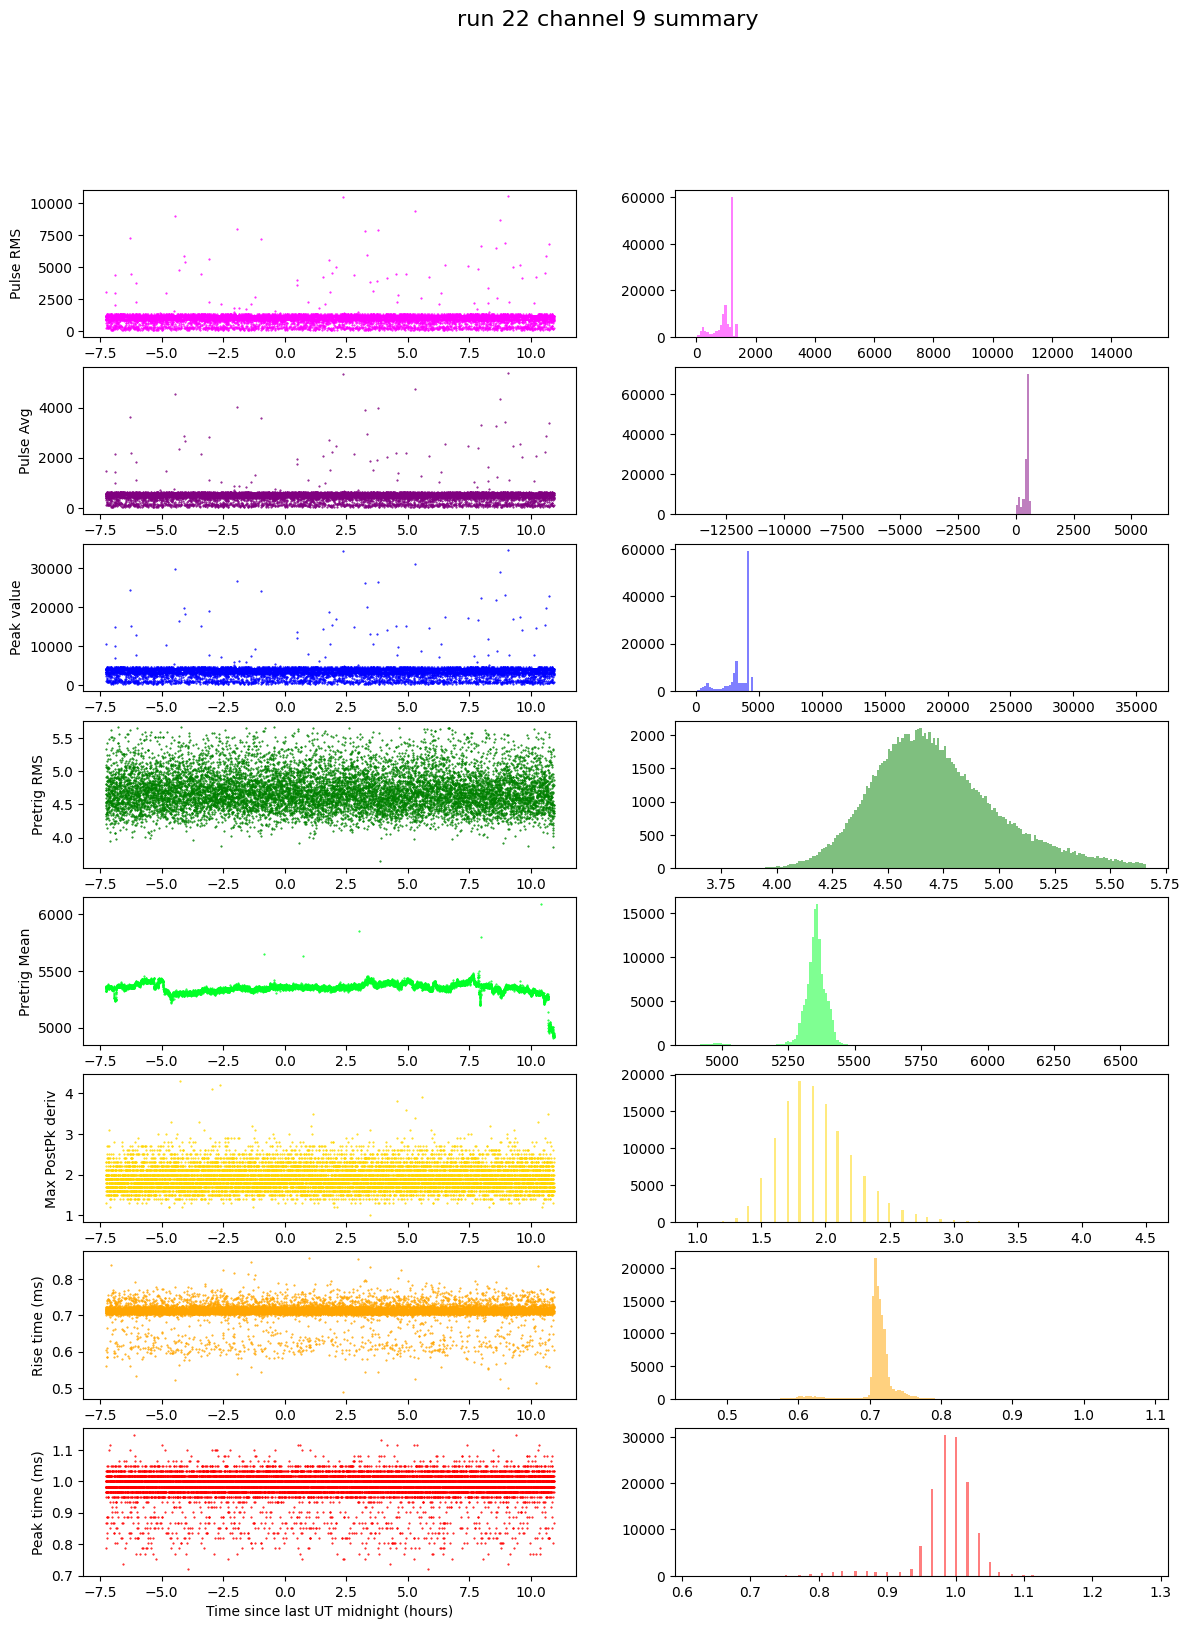

In [8]:
test_chan = 9
fig=plt.figure(figsize=(14,18))
data.channel[test_chan].plot_summaries()

plt.suptitle("run "+str(run_no)+" channel "+str(test_chan)+" summary", fontsize=16)
plt.savefig("run"+str(run_no)+"ch"+str(test_chan)+"_summaries.png")

Pause here and look at the pre-trigger mean for the run. Try to guess where the heater-out dropped below 12% or wherever the funny stuff starts. 

The flux jump corrector has a hard time fixing all the thermometry jumps. A fast fix is to just cut the uncorrected bits. 

In [9]:

#log the time cuts manually
timecut_sec={}

timecut_sec[22] = (data.channel[9].p_timestamp[0]+0*60,   data.channel[9].p_timestamp[0]+1075*60)

#apply the cut
timestamp_cuts = mass.controller.AnalysisControl(
    timestamp_sec=timecut_sec[run_no]  # INCLUDES pulses from -inf to unix timestamp 1771902941
)


#print('Applying timestamp cuts')
for ds in data.datasets: ds.apply_cuts(timestamp_cuts)


Chan 17 after cuts, 120885 are good, 11311 are bad of 132196 total pulses
Chan 18 after cuts, 113225 are good, 10992 are bad of 124217 total pulses
Chan 2 after cuts, 112060 are good, 9774 are bad of 121834 total pulses
Chan 20 after cuts, 127297 are good, 12999 are bad of 140296 total pulses
Chan 21 after cuts, 127493 are good, 14322 are bad of 141815 total pulses
Chan 22 after cuts, 126672 are good, 13706 are bad of 140378 total pulses
Chan 23 after cuts, 116460 are good, 13171 are bad of 129631 total pulses
Chan 24 after cuts, 121860 are good, 14308 are bad of 136168 total pulses
Chan 25 after cuts, 117637 are good, 13031 are bad of 130668 total pulses
Chan 3 after cuts, 121557 are good, 10882 are bad of 132439 total pulses
Chan 30 after cuts, 120350 are good, 12331 are bad of 132681 total pulses
Chan 31 after cuts, 120338 are good, 16438 are bad of 136776 total pulses
Chan 33 after cuts, 128005 are good, 16884 are bad of 144889 total pulses
Chan 34 after cuts, 128025 are good, 1595

Check if there are any stray PTM jumps 

/Users/roosa/Desktop/Spring2026/mass_analysis/mass_basic/../Utils/roosa_utils.py:68: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7,3.5))


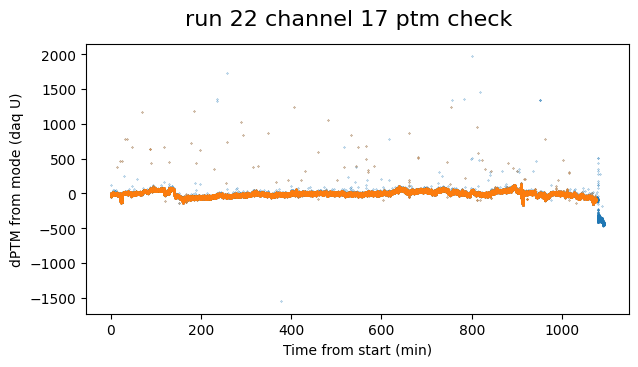

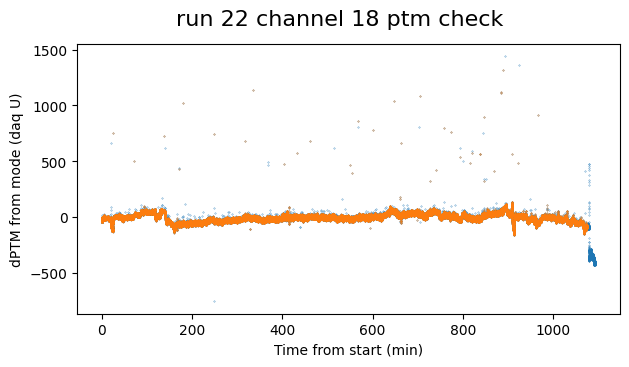

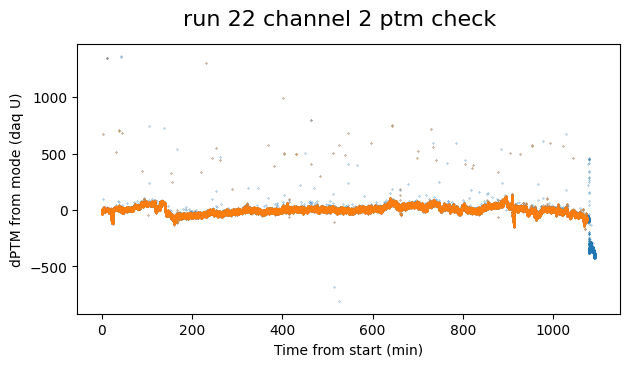

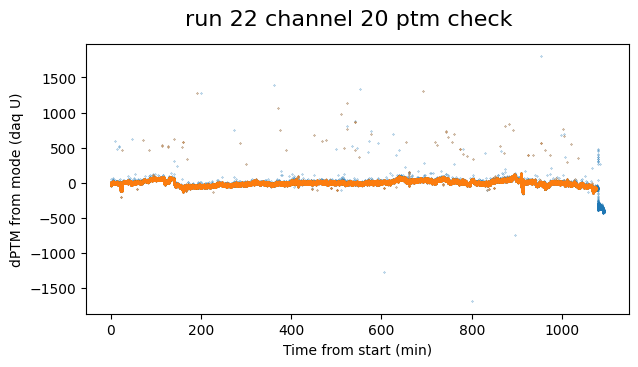

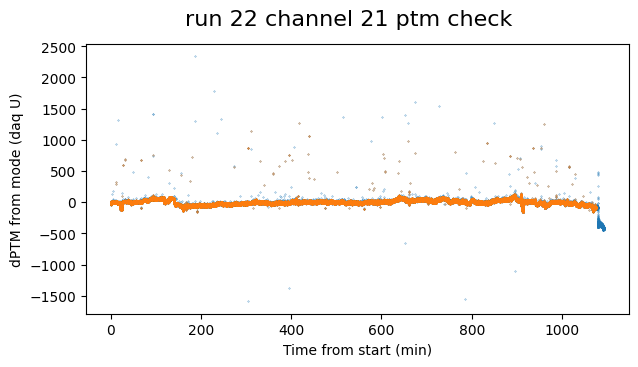

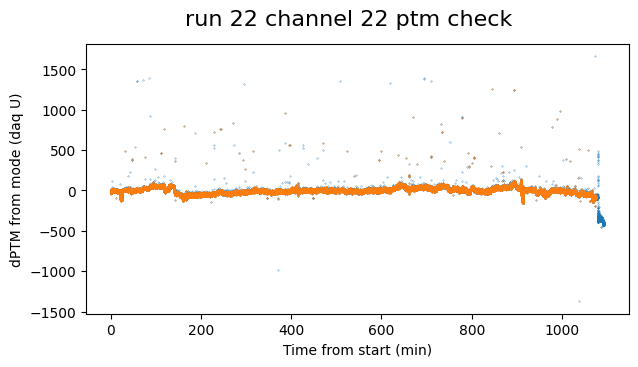

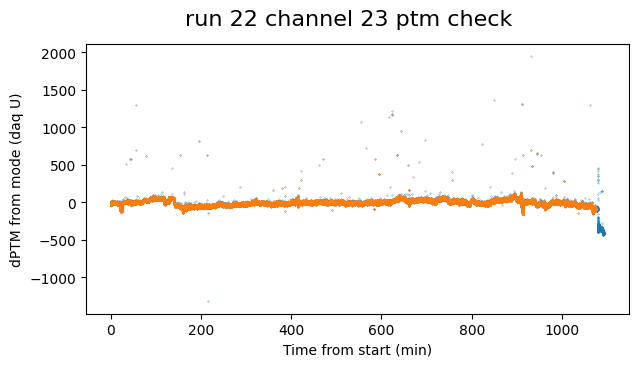

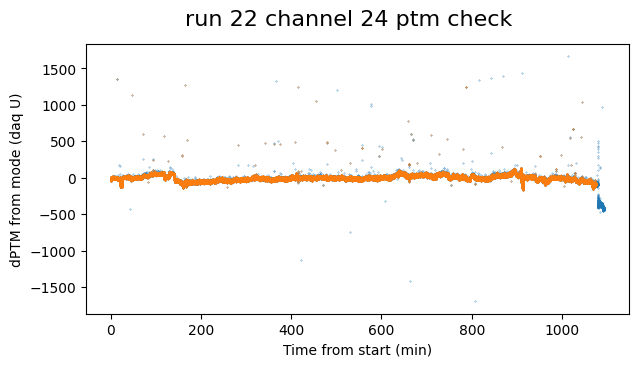

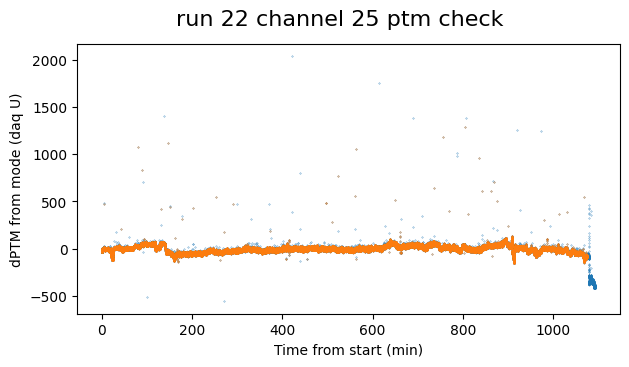

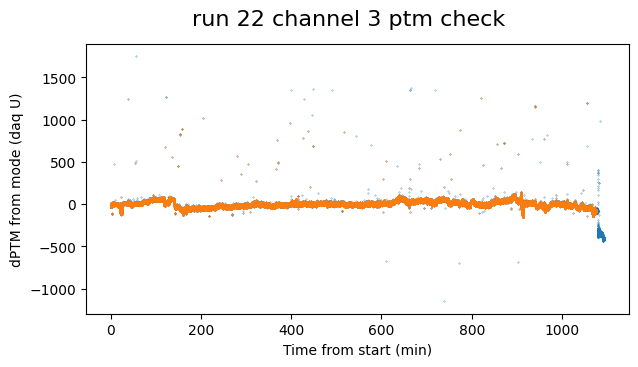

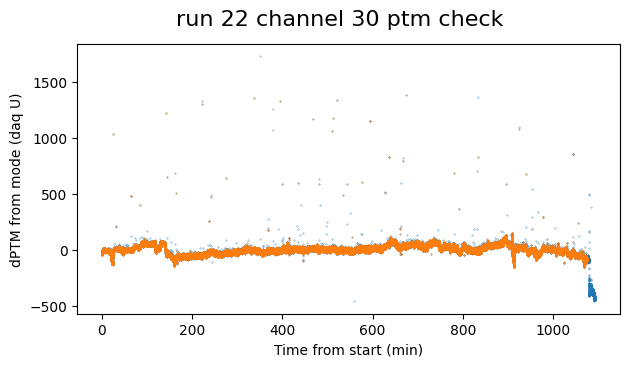

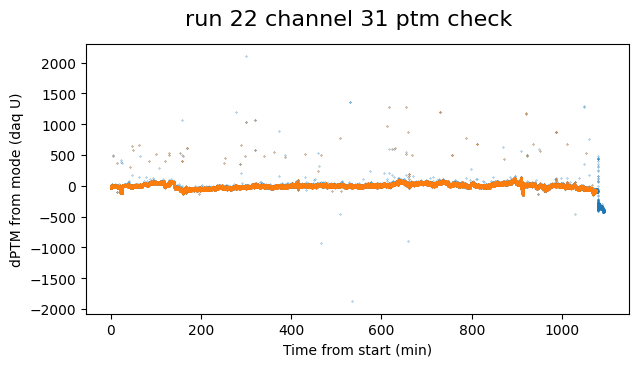

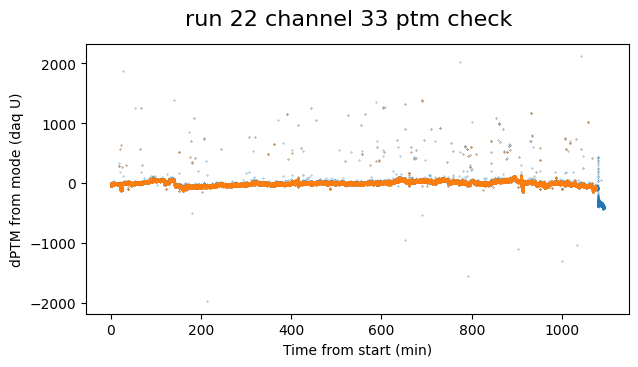

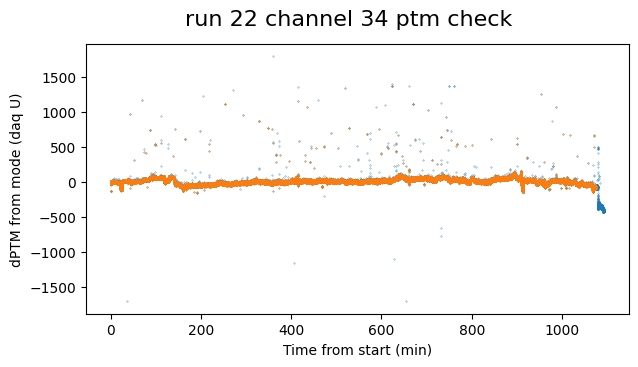

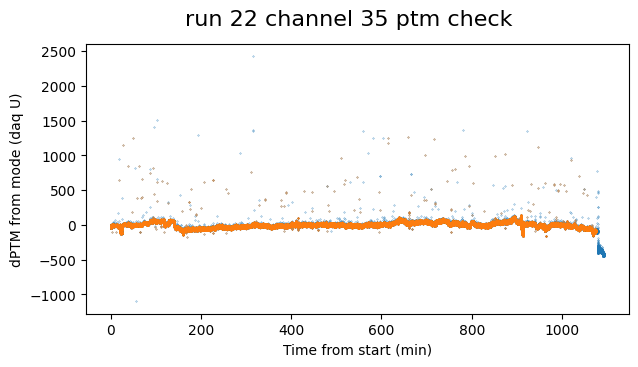

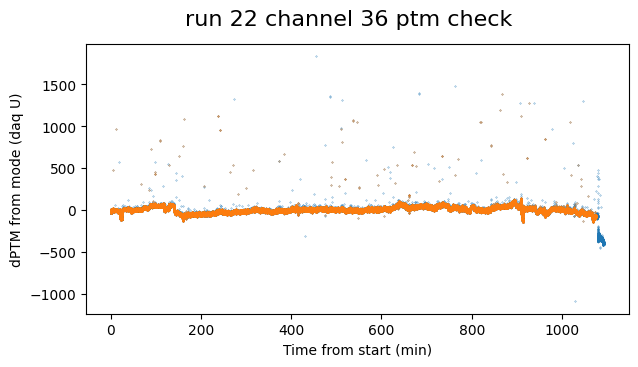

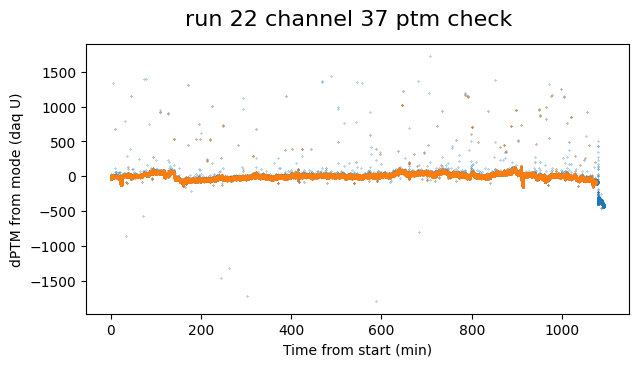

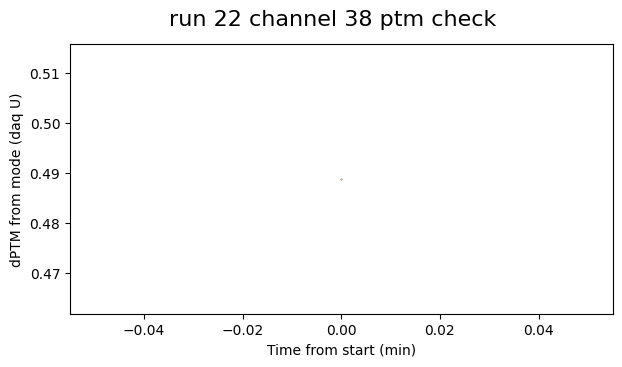

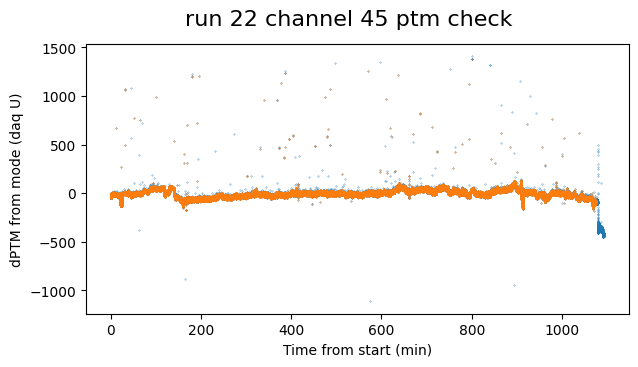

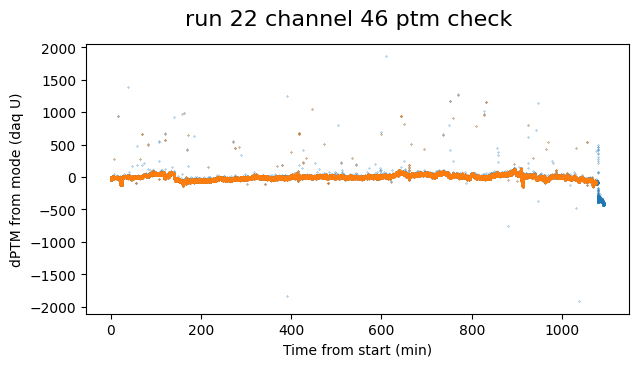

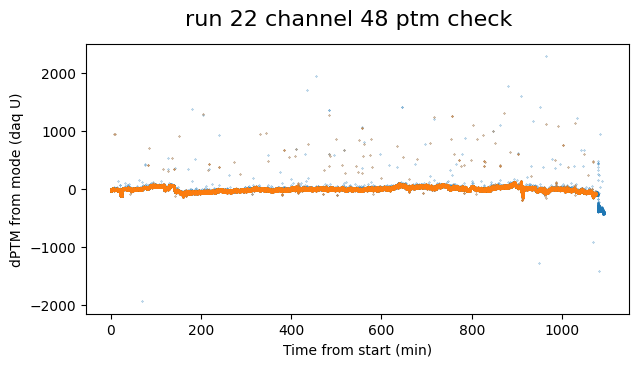

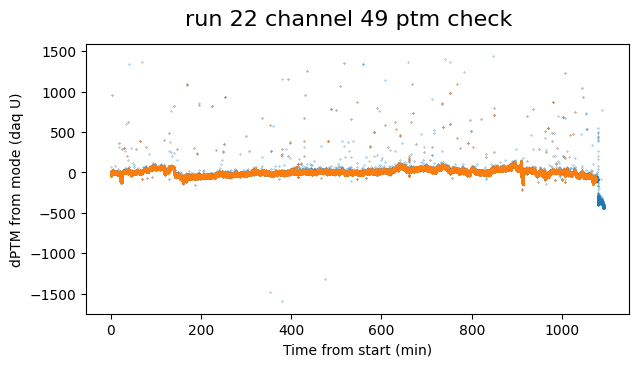

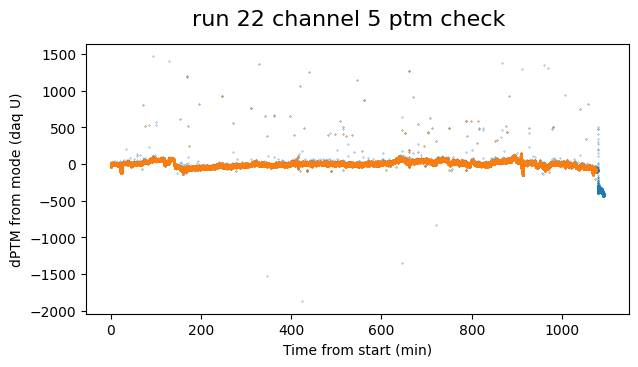

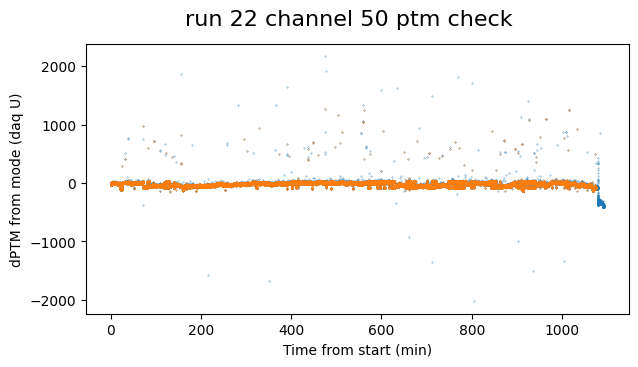

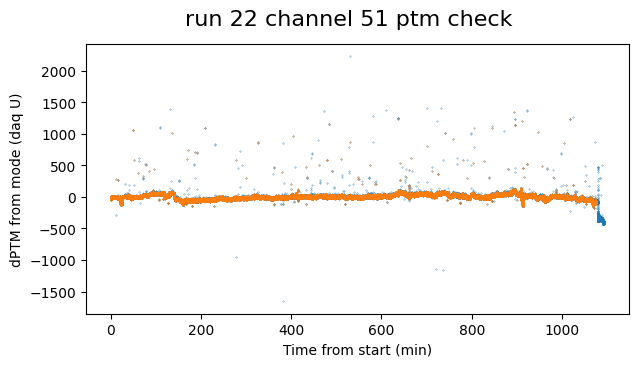

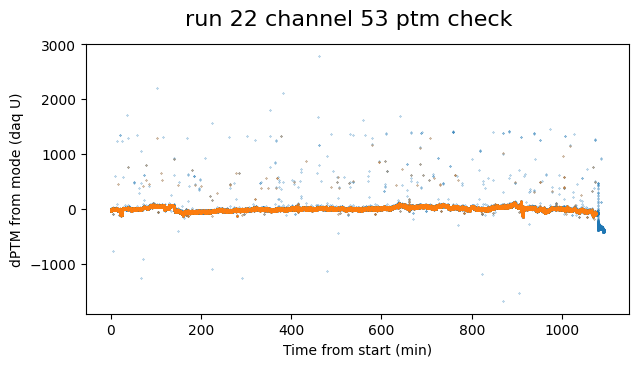

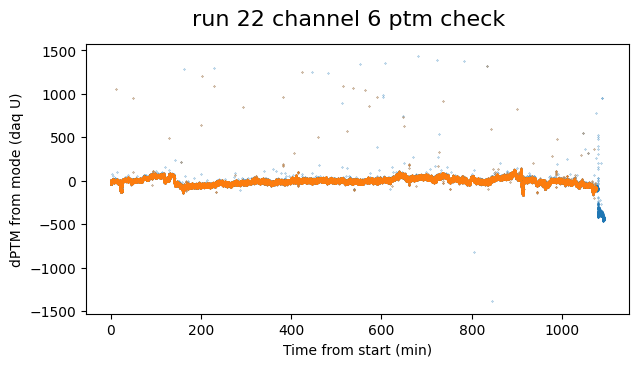

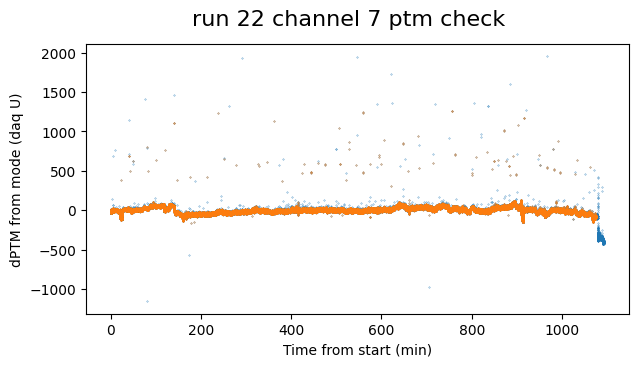

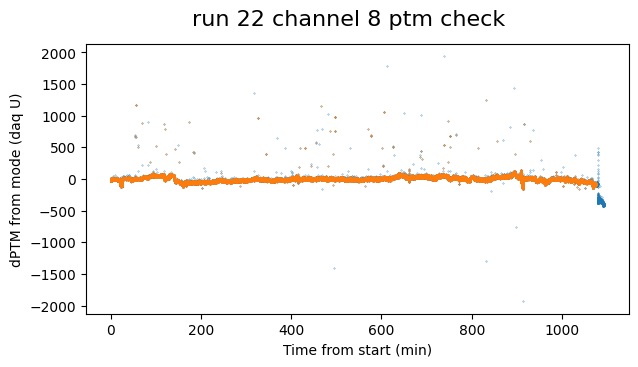

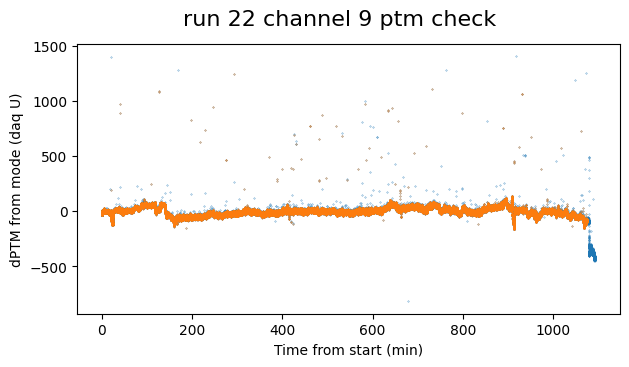

In [10]:
chans = data.good_channels # all data
for nn,ch in enumerate(chans): check_ptm(data, ch, run_no)

Scale the pulse integral (average) to energy for a coarse calibration. 
From here we can make a rough energy cut before building the optimal filter

/Users/roosa/Desktop/Spring2026/mass_analysis/mass_basic/../Utils/roosa_utils.py:25: RuntimeWarning: divide by zero encountered in divide
  return mass_variable[:]*norm/pk_val


Text(0.5, 1.0, 'run22 coadded pulse avg spectrum')

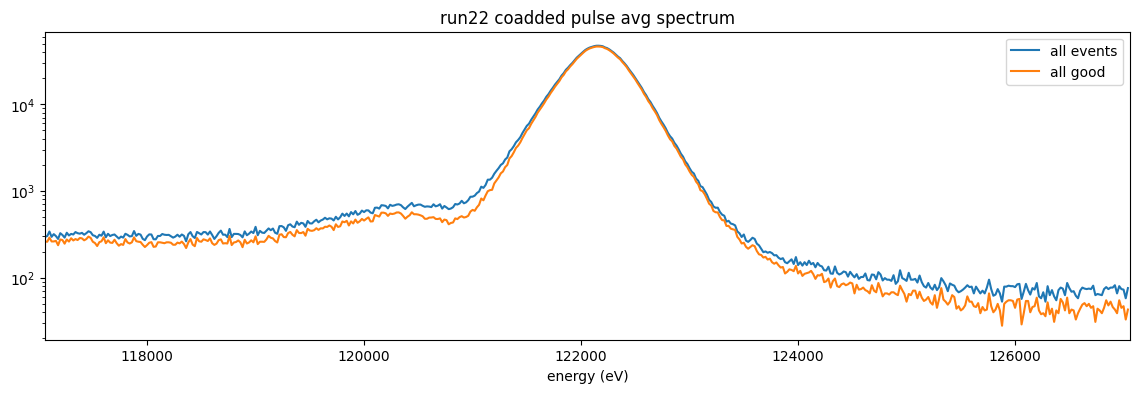

In [11]:
emin = g_57Co[0]-5e3
emax = g_57Co[0]+5e3
nbins_e = int((emax-emin)/(20))   #50 eV bins           

chans = data.good_channels # all data
all_histos_E = np.zeros((2, len(chans), nbins_e))
coaddE = np.zeros((2, nbins_e))


for nn,ch in enumerate(chans): 
    ds = data.channel[ch]
    g = ds.good()

    
    ds.p_pulse_average = mode_norm(ds.p_pulse_average, g, no_bins = 8000, search_range = [0, 8000], norm = g_57Co[0])
    #print(ch, pavg_mode)
    
    
    #emin *= g_57Co[0]/pavg_mode
    #emax *= g_57Co[0]/pavg_mode
    
    energy_range = (emin, emax)
    #print(energy_range)
    
    hE, bE  = np.histogram(ds.p_pulse_average, bins=nbins_e, range=energy_range)
    hEg, bEg = np.histogram(ds.p_pulse_average[g], bins=nbins_e, range=energy_range)
    all_histos_E[0,nn,:] = hE
    all_histos_E[1,nn,:] = hEg
    coaddE[0,:] += hE
    coaddE[1,:] += hEg 
    
    ebins = bE

plt.figure(figsize=(14,4))
plt.semilogy(ebins[:-1],coaddE[0,:], label = 'all events')
plt.semilogy(ebins[:-1],coaddE[1,:], label = 'all good')

maxval = hE.max() 
    

plt.xlim((emin, emax))
plt.xlabel(('energy (eV)'))
plt.legend()
plt.title("run"+str(run_no)+' coadded pulse avg spectrum')
#plt.savefig("run"+str(run_no)+"coadd_spectrum_nominal.png")




Make a histo of the risetimes and find the most likely value. 
Divide this out for a mode-normalized rise-time

In [12]:
#regularize the rise times 
for ch in data.good_channels:
    ds = data.channel[ch]
    g = ds.good()
 
    ds.p_rise_time[:] = mode_norm(ds.p_rise_time, g, no_bins=5000, search_range=(0.0005,.001))

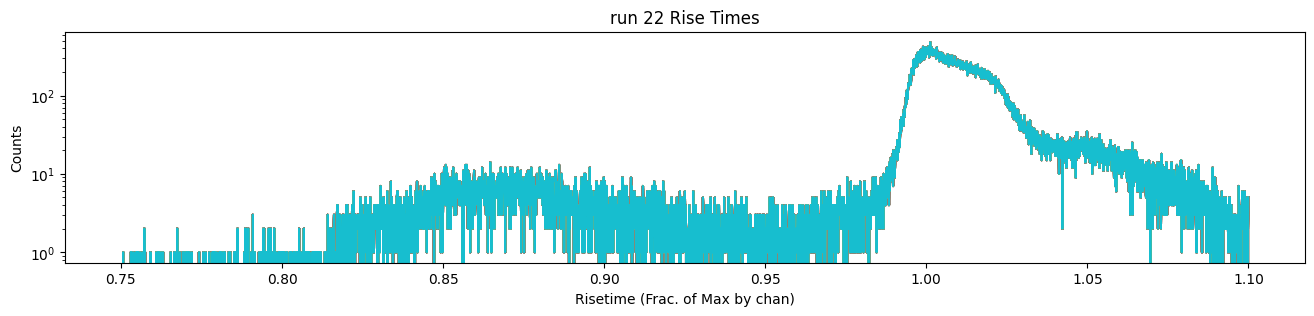

In [13]:
#regularize the rise times 
plt.figure(figsize=(16,3))
for ch in data.good_channels:
    ds = data.channel[9]
    g = ds.good()

    hRT, bRT  = np.histogram(ds.p_rise_time, bins=5000, range = (.75,1.1))

    plt.semilogy(bRT[:-1],hRT[:], label = 'all events')

plt.title("run "+str(run_no)+" Rise Times")
plt.xlabel(('Risetime (Frac. of Max by chan)'))
plt.ylabel(('Counts'))
    #plt.legend()
plt.savefig("rts"+str(run_no)+".png")

In [14]:
half_window = 250

mask_min = g_57Co[0]-half_window
mask_max = g_57Co[0]+half_window

masks = data.make_masks(pulse_avg_range=[mask_min,mask_max])

for nn,ch in enumerate(chans): 
    ds = data.channel[ch]
    g = ds.good()
    mask_temp =  np.logical_and(ds.p_rise_time[:]<1.01, ds.p_rise_time[:]>.98)
    masks[nn] = np.logical_and(masks[nn], mask_temp)

Make the average pulses and calculate the optimal filter 

In [15]:
#calculate filters 
data.compute_average_pulse(masks) 
#data.avg_pulses_auto_masks(forceNew=True)#also very suspiscious 

data.compute_5lag_filter(f_3db=500,forceNew=True)
data.filter_data(forceNew=True)

/Users/roosa/analysis/src/mass/mass/core/channel.py:1029: RuntimeWarning: Mean of empty slice
  average_pulse = self.data[mask, :].mean(axis=0)
/Users/roosa/analysis/lib/python3.14/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [16]:
#generate predicted e resolution 
for nn,ch in enumerate(chans): 
    print("channel "+str(ch))
    data.channel[ch].filter.report(g_57Co[0])
    print("")
    #print(ch, ds.filter.predicted_v_over_dv)

channel 17
v/δv:  1974.37, variance: 1.11 δE: 61.82 eV (FWHM), assuming standard E=122060.65 eV

channel 18
v/δv:  1921.91, variance: 0.58 δE: 63.51 eV (FWHM), assuming standard E=122060.65 eV

channel 2
v/δv:  2034.67, variance: 0.66 δE: 59.99 eV (FWHM), assuming standard E=122060.65 eV

channel 20
v/δv:  1666.82, variance: 0.90 δE: 73.23 eV (FWHM), assuming standard E=122060.65 eV

channel 21
v/δv:  1934.14, variance: 1.14 δE: 63.11 eV (FWHM), assuming standard E=122060.65 eV

channel 22
v/δv:  1883.00, variance: 1.07 δE: 64.82 eV (FWHM), assuming standard E=122060.65 eV

channel 23
v/δv:  827.84, variance: 3.51 δE: 147.44 eV (FWHM), assuming standard E=122060.65 eV

channel 24
v/δv:  1887.33, variance: 0.85 δE: 64.67 eV (FWHM), assuming standard E=122060.65 eV

channel 25
v/δv:  2230.68, variance: 0.54 δE: 54.72 eV (FWHM), assuming standard E=122060.65 eV

channel 3
v/δv:  1733.50, variance: 1.19 δE: 70.41 eV (FWHM), assuming standard E=122060.65 eV

channel 30
v/δv:  520.27, varian

chan 17 best drift correction parameter: 10.628978e6
chan 18 best drift correction parameter: 8.117529e6
chan 2 best drift correction parameter: 6.489342e6
chan 20 best drift correction parameter: 11.425550e6
chan 21 best drift correction parameter: 11.439465e6
chan 22 best drift correction parameter: 12.474636e6
chan 23 best drift correction parameter: 9.387876e6
chan 24 best drift correction parameter: 8.918518e6
chan 25 best drift correction parameter: 9.168650e6
chan 3 best drift correction parameter: 9.503642e6
chan 30 best drift correction parameter: 5.058155e6
chan 31 best drift correction parameter: 13.954011e6
chan 33 best drift correction parameter: 12.691804e6
chan 34 best drift correction parameter: 10.732687e6
chan 35 best drift correction parameter: 10.424644e6
chan 36 best drift correction parameter: 11.196960e6
chan 37 best drift correction parameter: 10.126969e6
traceback:
['Traceback (most recent call last):\n', '  File "/Users/roosa/analysis/src/mass/mass/core/channe

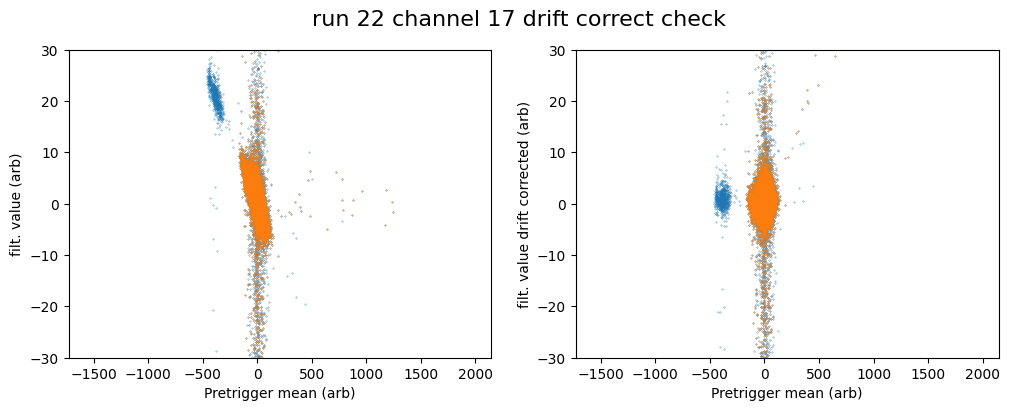

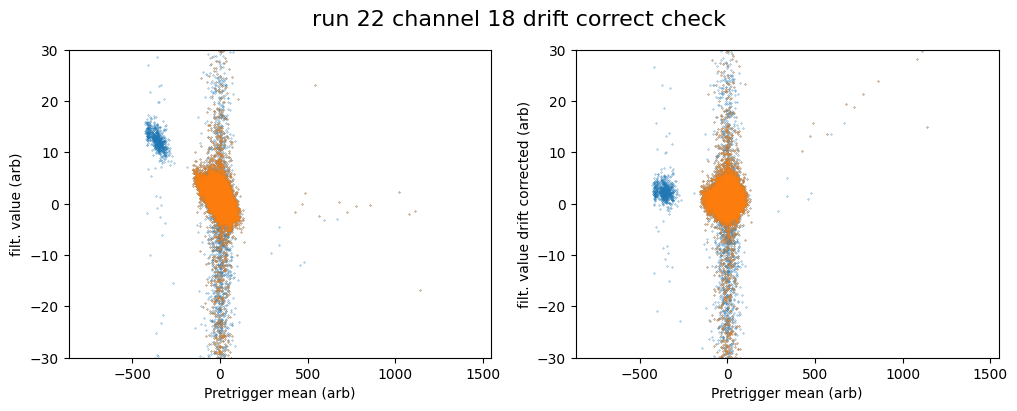

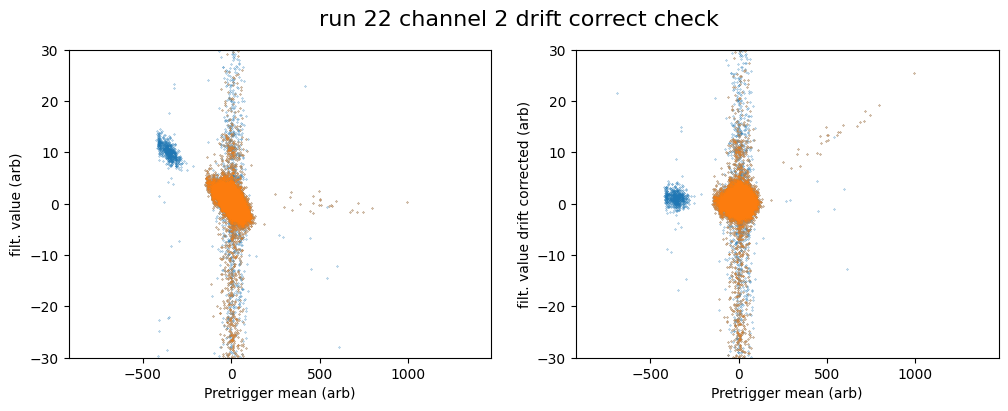

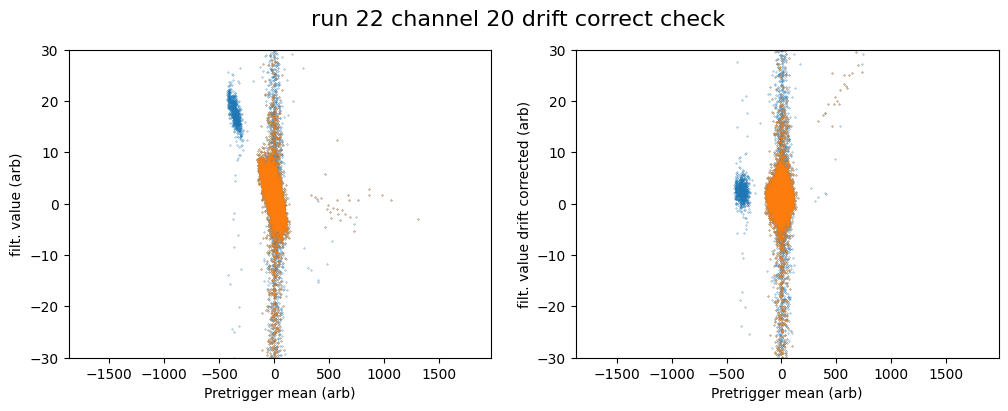

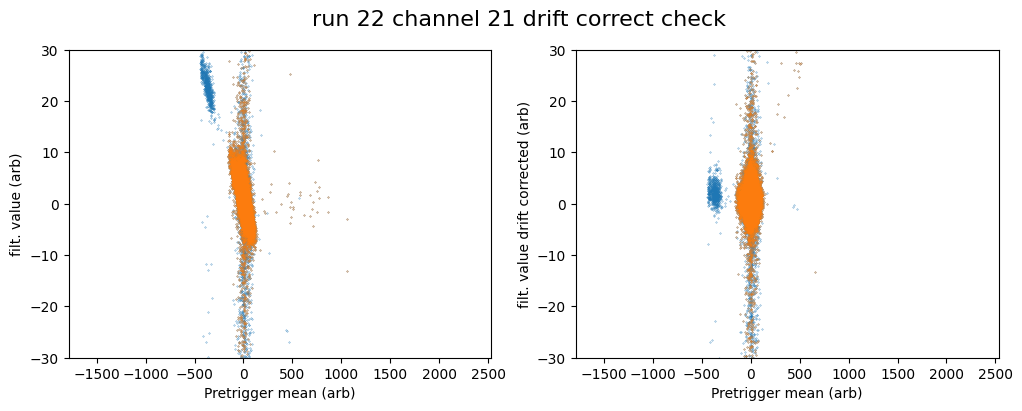

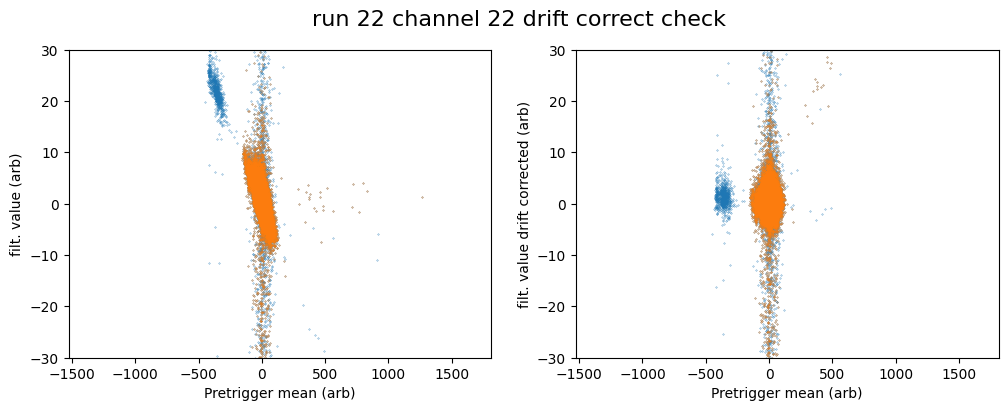

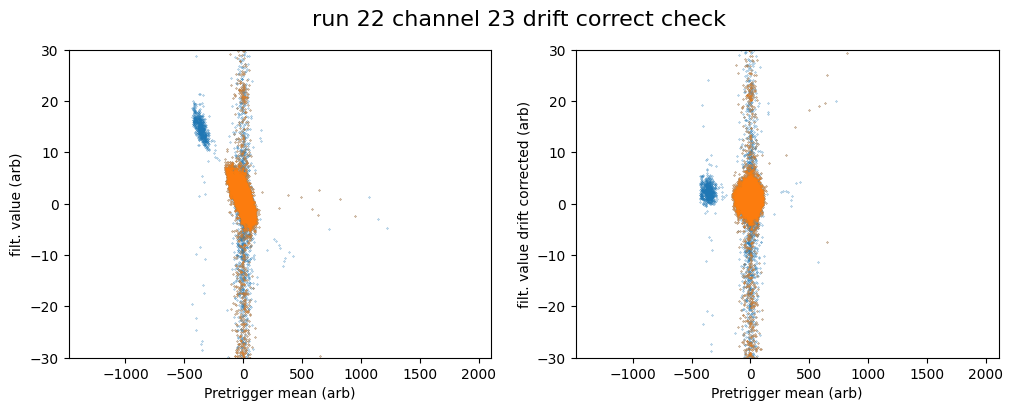

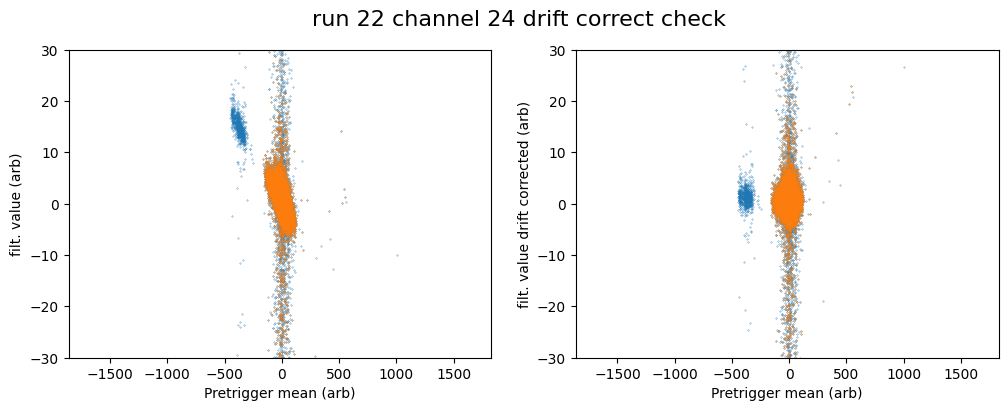

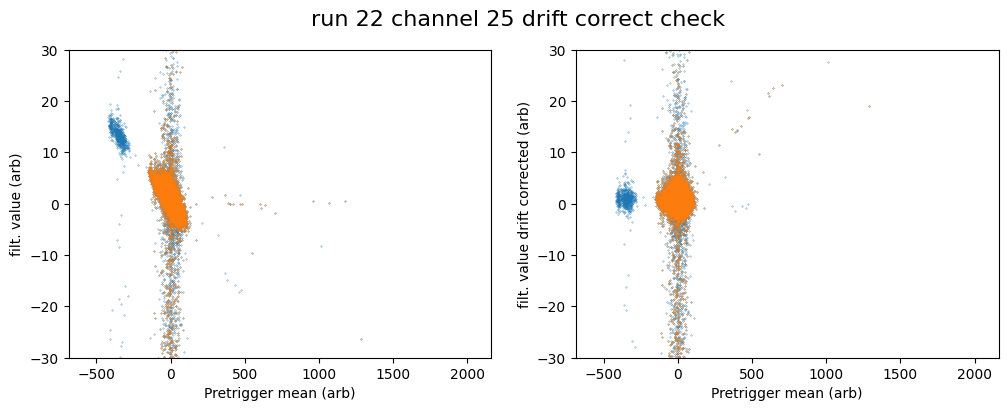

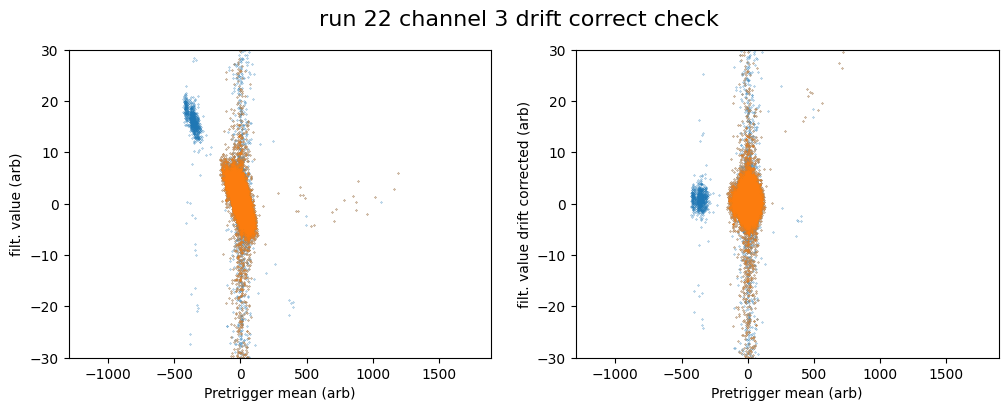

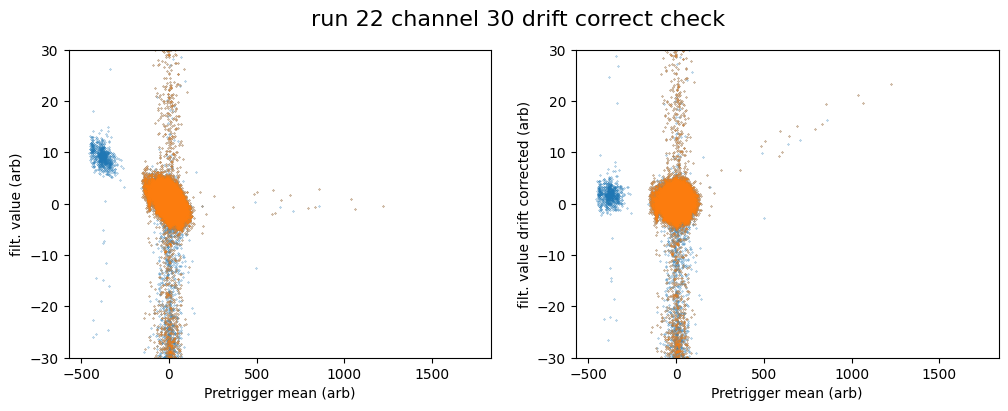

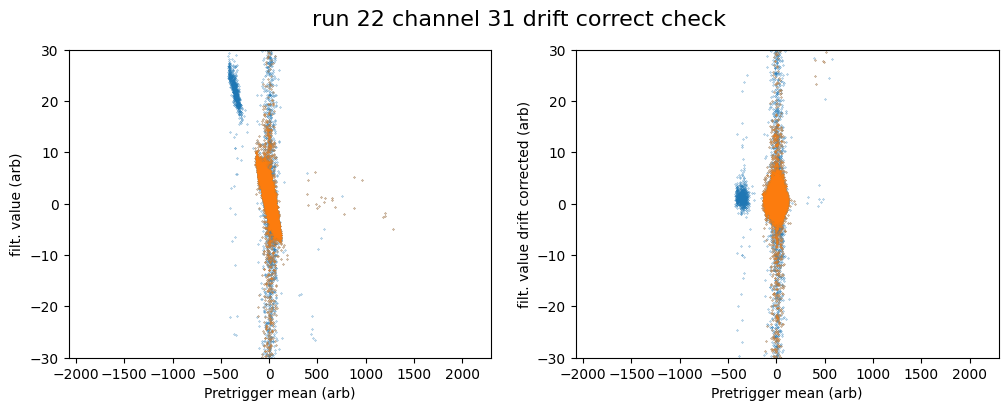

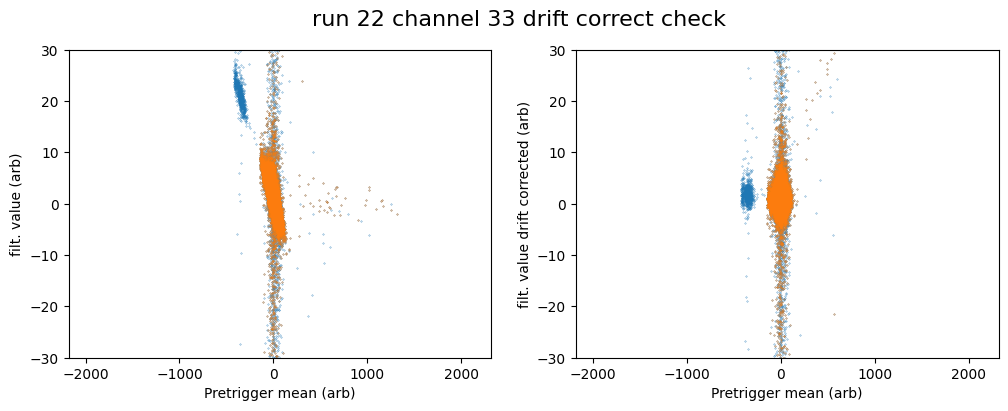

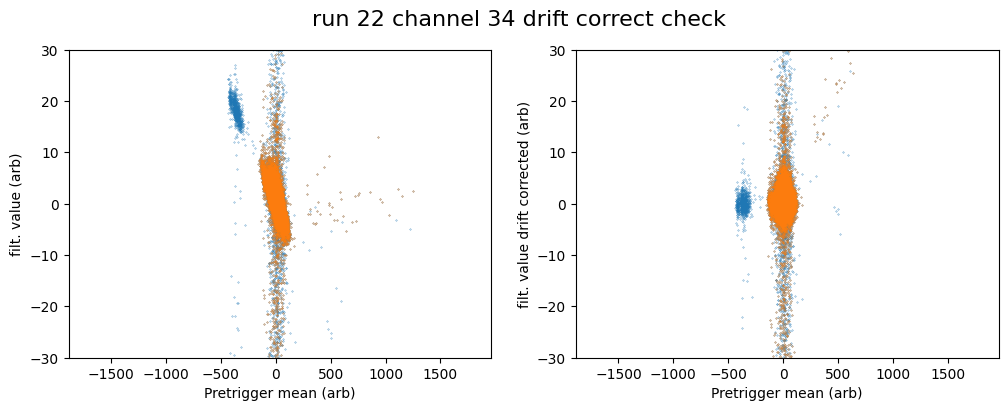

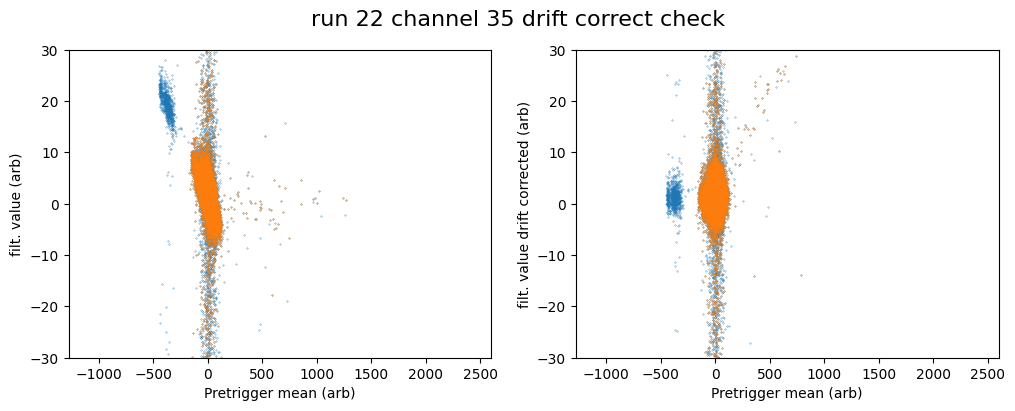

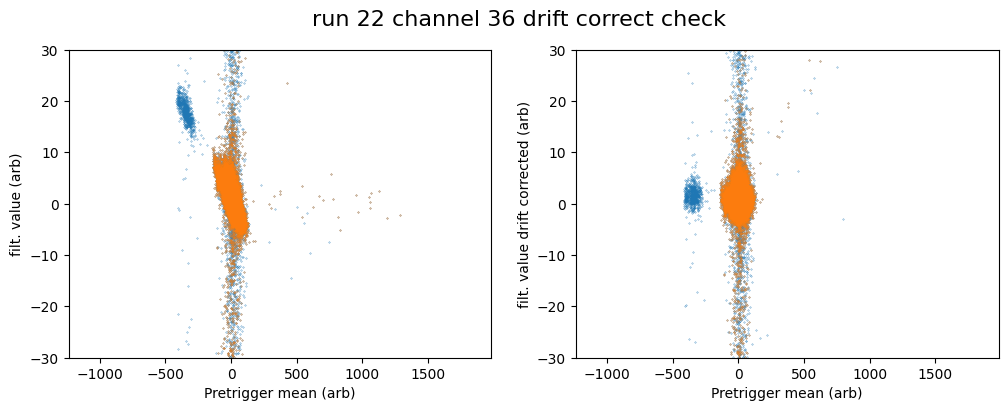

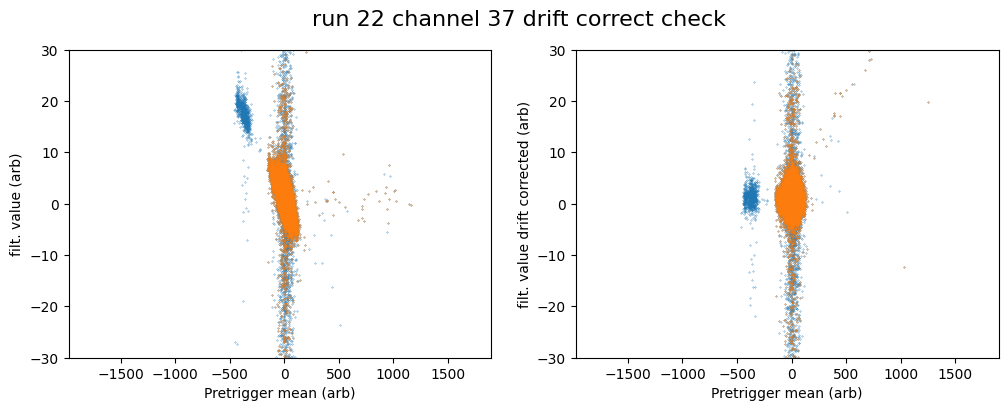

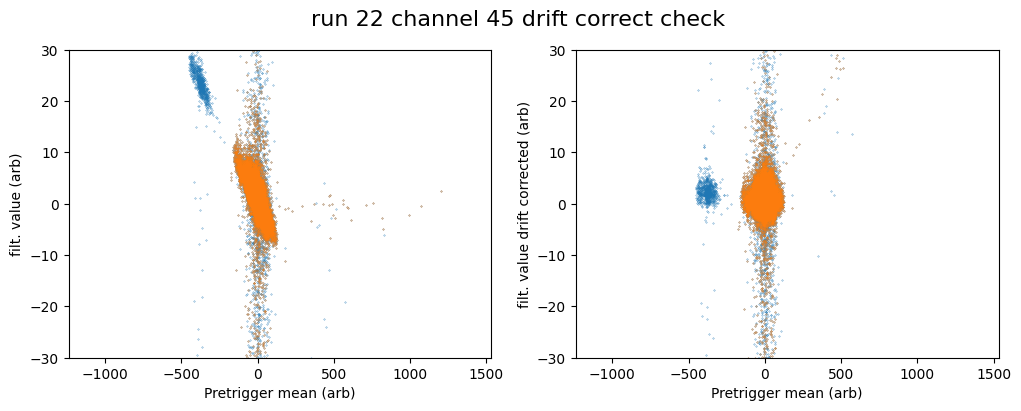

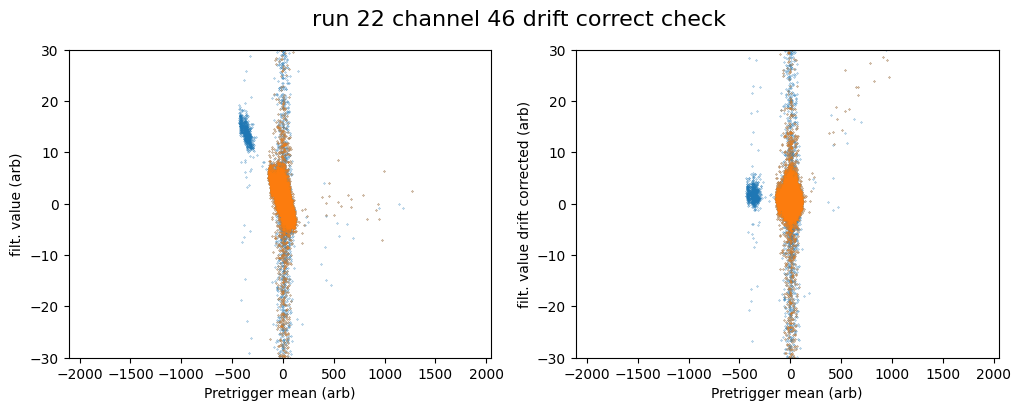

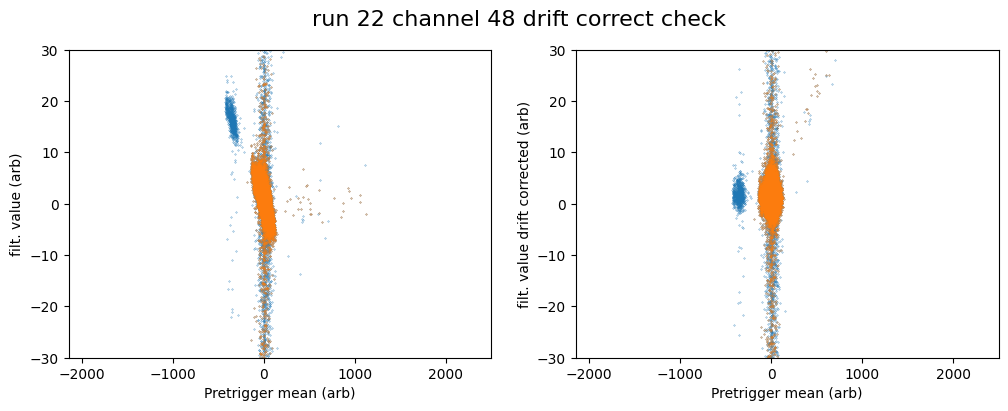

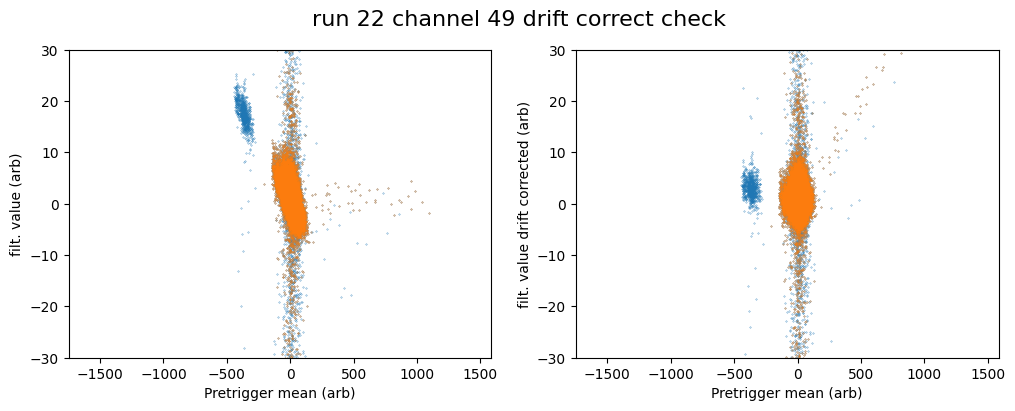

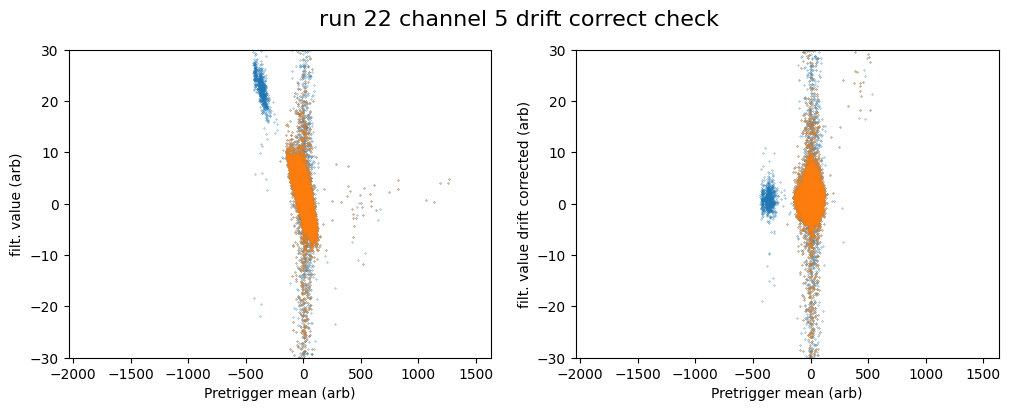

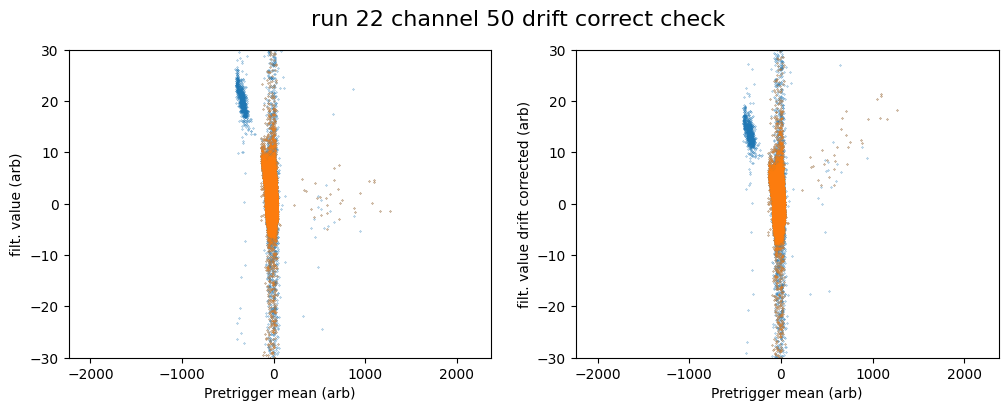

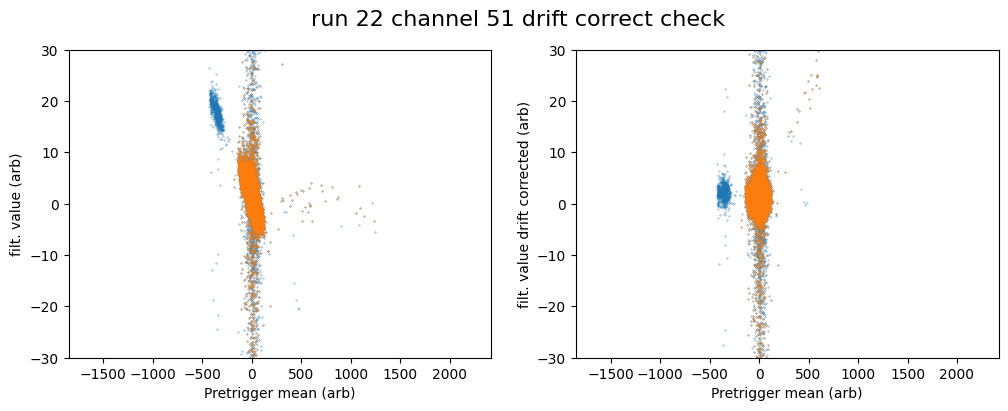

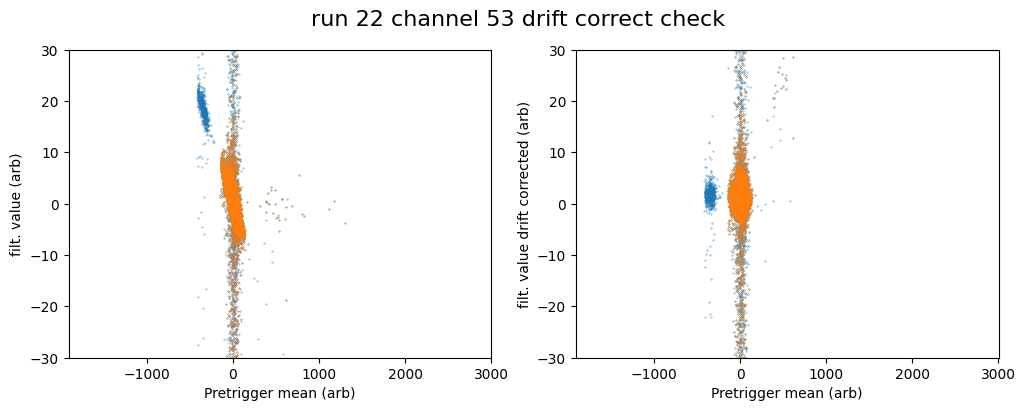

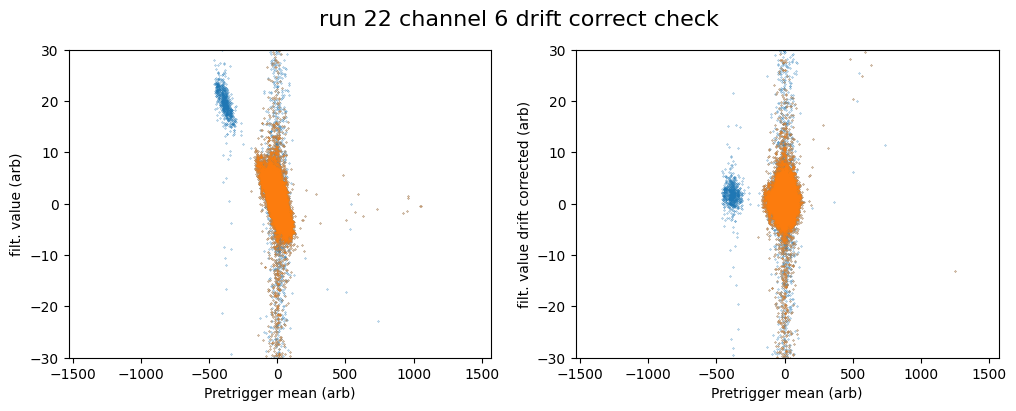

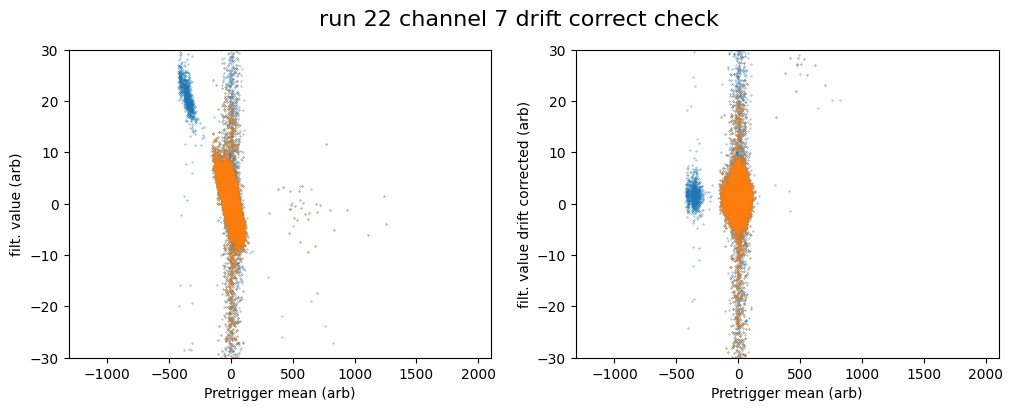

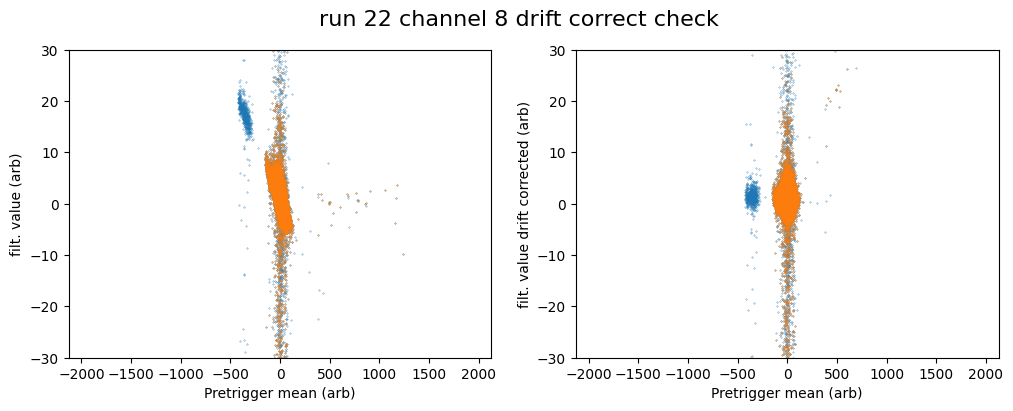

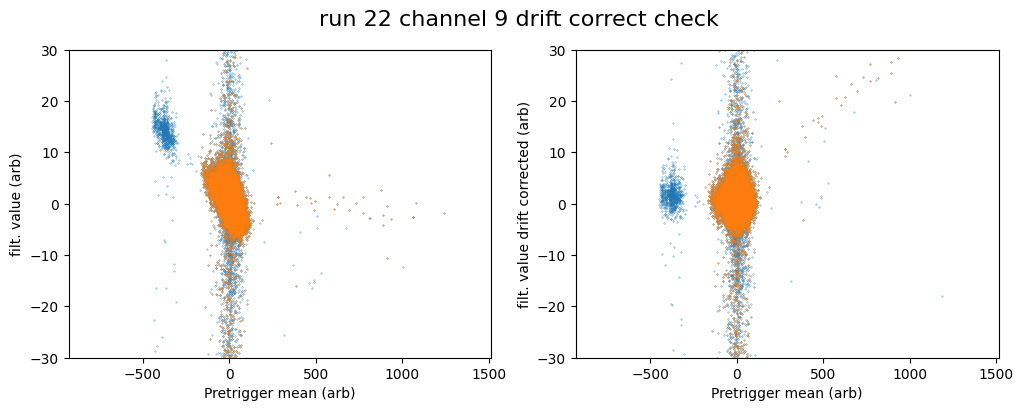

In [17]:
#apply drift correction
data.drift_correct(forceNew=True)
data.phase_correct(forceNew=True) #highly suspicious -> maybe extra 

chans = data.good_channels # all data
for nn,ch in enumerate(chans): check_dc(data, ch, run_no)

In [18]:
#applys the dc style entropy minimizer to the median filt value over time
data.time_drift_correct(forceNew=True)

chan 17 doing time_drift_correct
Using 20 degrees for  52416 photons (after 2 downsample)
That's 2620.8 photons per degree, and 3224.9 seconds per degree.
chan 18 doing time_drift_correct
Using 20 degrees for  50156 photons (after 2 downsample)
That's 2507.8 photons per degree, and 3224.9 seconds per degree.
chan 2 doing time_drift_correct
Using 20 degrees for  49788 photons (after 2 downsample)
That's 2489.4 photons per degree, and 3224.9 seconds per degree.
chan 20 doing time_drift_correct
Using 20 degrees for  55599 photons (after 2 downsample)
That's 2779.9 photons per degree, and 3225.0 seconds per degree.
chan 21 doing time_drift_correct
Using 20 degrees for  55296 photons (after 2 downsample)
That's 2764.8 photons per degree, and 3224.9 seconds per degree.
chan 22 doing time_drift_correct
Using 20 degrees for  54882 photons (after 2 downsample)
That's 2744.1 photons per degree, and 3225.0 seconds per degree.
chan 23 doing time_drift_correct
Using 20 degrees for  51408 photons (a

In [19]:
my_cal = []#[93.574e3, 97.016e3, 122.06065e3, 136.47356e3]

my_cal.extend(g_57Co)
my_cal.extend(give_escapes(g_57Co, x_Sn[0:1]))

my_cal.sort()
print(my_cal)

for i,ds in enumerate(data):
    #g = ds.good()
    print('Working on channel %d'%ds.channum)
    
    try:
        #cal initial
        ds.calibrate('p_filt_value_tdc',line_names=my_cal,forceNew=True)
    except:
        print('failed to calibrate ch '+str(ds.channum))

Calibrating chan 17 to create p_filt_value_tdc
Calibrating chan 18 to create p_filt_value_tdc
Calibrating chan 2 to create p_filt_value_tdc


[96789.34999999999, 111202.26, 122060.65, 136473.56]
Working on channel 17
Working on channel 18
Working on channel 2


Calibrating chan 20 to create p_filt_value_tdc
Calibrating chan 21 to create p_filt_value_tdc
Calibrating chan 22 to create p_filt_value_tdc
Calibrating chan 23 to create p_filt_value_tdc
Calibrating chan 24 to create p_filt_value_tdc


Working on channel 20
Working on channel 21
Working on channel 22
Working on channel 23
Working on channel 24


Calibrating chan 25 to create p_filt_value_tdc
Calibrating chan 3 to create p_filt_value_tdc


...

Working on channel 36
Working on channel 37
Working on channel 45
Working on channel 46
Working on channel 48


Calibrating chan 49 to create p_filt_value_tdc
Calibrating chan 5 to create p_filt_value_tdc
Calibrating chan 50 to create p_filt_value_tdc
Calibrating chan 51 to create p_filt_value_tdc
Calibrating chan 53 to create p_filt_value_tdc


Working on channel 49
Working on channel 5
Working on channel 50
Working on channel 51
Working on channel 53


Calibrating chan 6 to create p_filt_value_tdc
Calibrating chan 7 to create p_filt_value_tdc
Calibrating chan 8 to create p_filt_value_tdc
Calibrating chan 9 to create p_filt_value_tdc


Working on channel 6
Working on channel 7
Working on channel 8
Working on channel 9


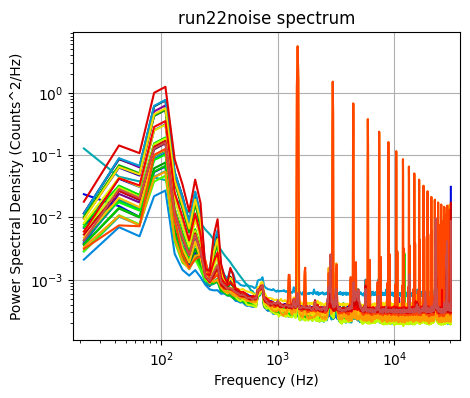

In [20]:
###### plot noise
plt.figure(figsize=(5,4))
data.plot_noise(legend=False)
plt.title("run"+str(run_no)+'noise spectrum')
plt.savefig("run"+str(run_no)+"_noise.png")

In [21]:
''' 
Energy Histogram
0: all events 
1: all good events
'''

energy_range = (0,350e3) #0 - 350keV
nbins_e = int((350e3)/(50))   #50 eV bins           

chans = data.good_channels # all data
all_histos_E = np.zeros((2, len(chans), nbins_e))
coaddE = np.zeros((2, nbins_e))

for nn,ch in enumerate(chans): 
    ds = data.channel[ch]
    g = ds.good()
    
    hE, bE  = np.histogram(ds.p_energy[:], bins=nbins_e, range=energy_range)
    hEg, bEg = np.histogram(ds.p_energy[g], bins=nbins_e, range=energy_range)
    all_histos_E[0,nn,:] = hE
    all_histos_E[1,nn,:] = hEg
    coaddE[0,:] += hE
    coaddE[1,:] += hEg 
    
ebins = bE

Text(0.5, 1.0, 'offset energy spectra by channel')

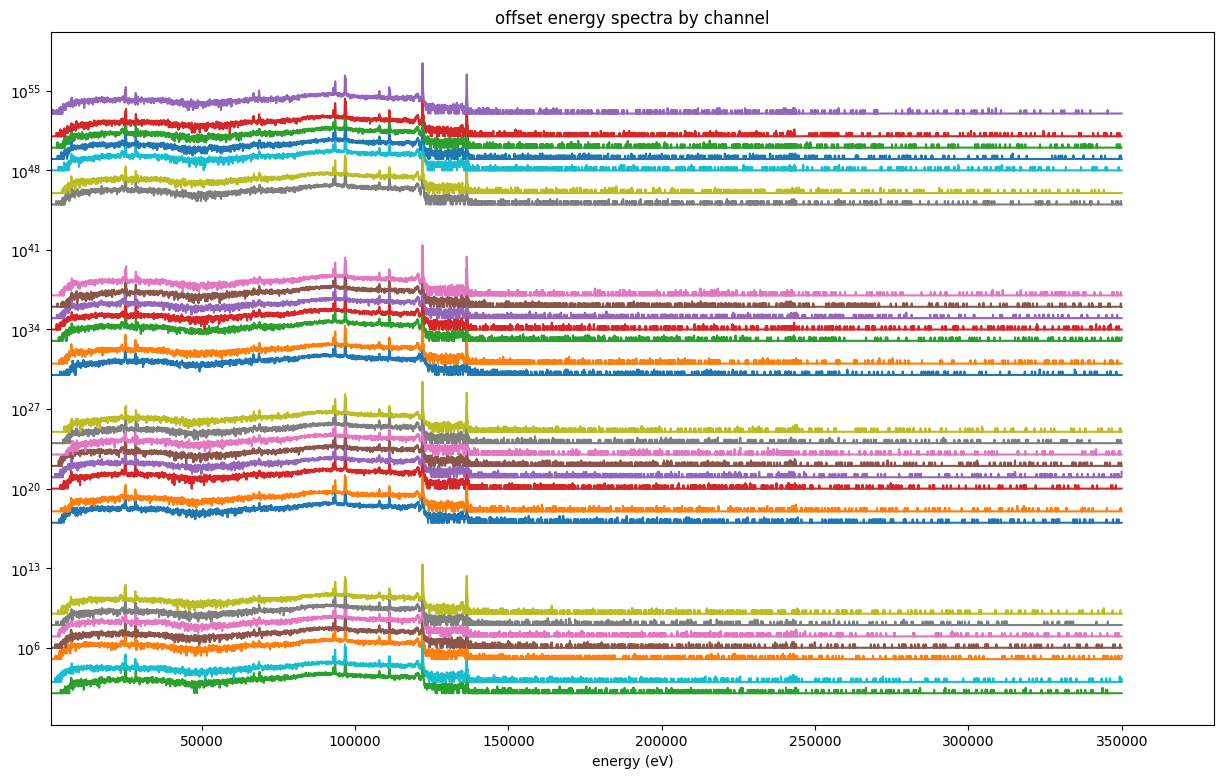

In [22]:
chans = data.good_channels # all data
plt.figure(figsize=(15,9))
for nn, ch in enumerate(chans):
    
    #plt.semilogy(ebins[:-1],all_histos_E[0,nn,:]+nn, label = 'all events')
    #calculate a log scale offset by chan
    #offset = 1000**(float(ch)/128)
    #calculate a lin scale offset by chan
    offset = 10**ch
    plt.plot(ebins[:-1], (all_histos_E[1,nn,:]+1)*offset, label = 'all good')

plt.yscale("log")
plt.xlim((1e3, 380e3))
plt.xlabel(('energy (eV)'))
#plt.legend()
plt.title('offset energy spectra by channel')   

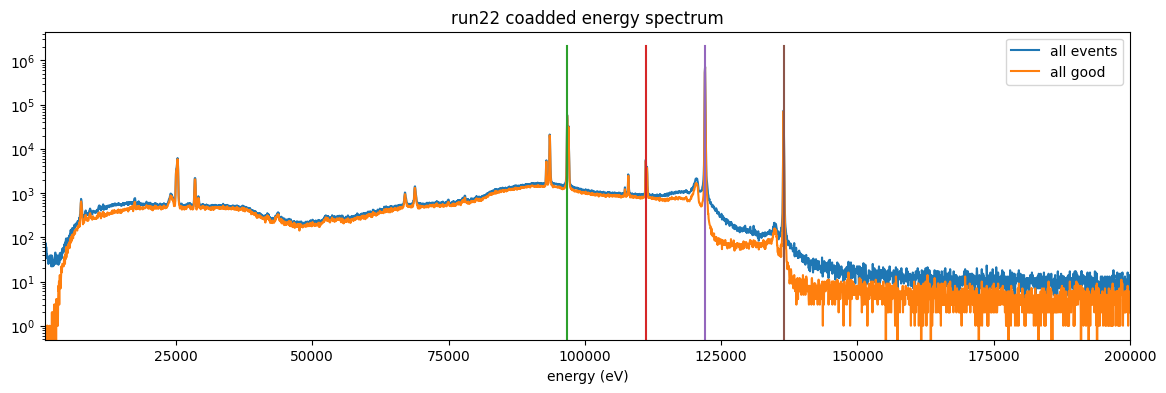

In [23]:
plt.figure(figsize=(14,4))
plt.semilogy(ebins[:-1],coaddE[0,:], label = 'all events')
plt.semilogy(ebins[:-1],coaddE[1,:], label = 'all good')

maxval = hE.max() 

for line in my_cal: 
    plt.plot([line,line],[0, maxval*1e2])
    

plt.xlim((1e3, 200e3))
plt.xlabel(('energy (eV)'))
plt.legend()
plt.title("run"+str(run_no)+' coadded energy spectrum')
plt.savefig("run"+str(run_no)+"coadd_spectrum_nominal.png")

In [24]:
#Calculate the time since trigger 
dt_trig = {} #for time since nearest preceding trigger 
id_trig = {} #index for above

for ch in data.good_channels: #loop channels
    ds = data.channel[ch] 
    dt_trig_ch = [] #by chan place holder
    id_trig_ch = [] #by chan place holder 
    for i in range(ds.nPulses): #loop pulses 
        #make array of 
        t_from_trigger = np.array(ds.p_subframecount[i]-data.external_trigger_subframe_count[:])
        #t_from_trigger = t_from_trigger[t_from_trigger>0]
        min_time_arg = np.abs(t_from_trigger).argmin()
        dt_trig_ch.append(t_from_trigger[min_time_arg])
        id_trig_ch.append(min_time_arg)
    dt_trig[ch]= np.asarray(dt_trig_ch)*data.subframe_timebase*1000 #ms ? 
    id_trig[ch]= np.asarray(id_trig_ch)

In [25]:
''' 
Prompt Energy Histogram
0: all events 
1: all good events
'''

energy_range = (0,350e3) #0 - 350keV
nbins_e = int((350e3)/(50))   #50 eV bins           

chans = data.good_channels # all data
all_histos_EP = np.zeros((2, len(chans), nbins_e))
coaddEP = np.zeros((2, nbins_e))

for nn,ch in enumerate(chans): 
    #if ch !=21: continue
    ds = data.channel[ch]
    g = ds.good()
    prompt = np.logical_and(dt_trig[ch]>1.03, dt_trig[ch]<1.07)
    good_risetime = ds.p_rise_time[:]>.95
    gprompt = np.logical_and(g, prompt, good_risetime)
    
    hEP, bEP   = np.histogram(ds.p_energy[prompt],  bins=nbins_e, range=energy_range)
    hEPg, bEPg = np.histogram(ds.p_energy[gprompt], bins=nbins_e, range=energy_range)
    all_histos_EP[0,nn,:] = hEP
    all_histos_EP[1,nn,:] = hEPg
    coaddEP[0,:] += hEP
    coaddEP[1,:] += hEPg 
    
ebins = bEP

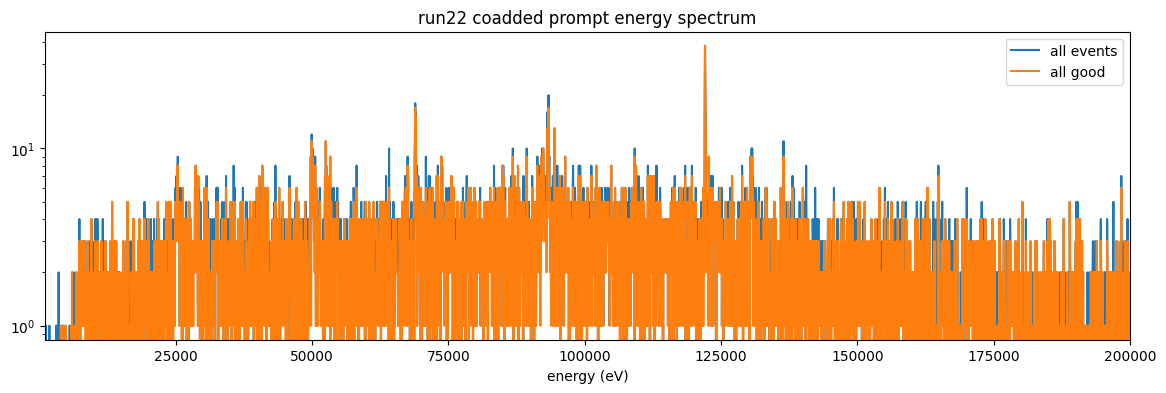

In [26]:
plt.figure(figsize=(14,4))
plt.semilogy(ebins[:-1],coaddEP[0,:], label = 'all events')
plt.semilogy(ebins[:-1],coaddEP[1,:], label = 'all good')

#maxval = hEP.max() 

plt.xlim((1e3, 200e3))
plt.xlabel(('energy (eV)'))
plt.legend()
plt.title("run"+str(run_no)+' coadded prompt energy spectrum')
plt.savefig("run"+str(run_no)+"coadd_prompt_spectrum_nominal.png")

In [27]:
#calulate the time between each trigger
trigger_times = data.external_trigger_subframe_count[:]*data.subframe_timebase * 1000
spill_id, mb_id = calc_spill_mb_no(trigger_times, 110) #spill threshold in ms

#Finally, make the coadded 
#recall
#dt_trig = {} #for time since nearest preceding trigger 
#id_trig = {} #index for above
coadded_mb_id = np.array([])
coadded_sp_id = np.array([])

for ch in data.good_channels:
    coadded_mb_id = np.append(coadded_mb_id, mb_id[id_trig[ch]])
    coadded_sp_id = np.append(coadded_sp_id, spill_id[id_trig[ch]])
    
    if len(mb_id[id_trig[ch]])!=len(data.channel[ch].p_filt_value): print("MB and Spill assignment failed for ch ",ch)